# ML-отчёт: АВТ → гидроочистка → оптимизация

Все числа и графики ниже строятся из локальных артефактов обучения и финального временного test-среза — синтетические метрики не используются.

**Что проверяем:**

1. качество прогноза относительно факта и ВАК-baseline;
2. coverage 90%-интервалов и риск превышения серы 10 мг/кг;
3. локальное SHAP-объяснение прогноза серы;
4. Парето-фронт допустимых управляющих воздействий на реальной demo-точке.

## Методика и защита от утечки

Разбиение не перемешивается: train `2023-01-01…2024-12-31`, validation `2025-01-01…2025-06-30`, test `2025-07-01…2026-08-07`. Интервал test-точки калибруется только по ошибкам, известным до неё (окно из 30 предыдущих меток, история начинается на validation). Для редких ЛИМС-таргетов учитывается только момент появления нового анализа.

Перед запуском выполните из корня проекта `make train`. Для графиков в kernel должны быть доступны `matplotlib` и зависимости из `backend/requirements.txt`.

In [8]:
from __future__ import annotations

import json
import logging
import sys
import time
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Контрастная палитра, одинаковая для всех графиков отчёта.
PALETTE = {
    "ink": "#14213D",
    "blue": "#0066FF",
    "cyan": "#00A6D6",
    "orange": "#FF7A00",
    "red": "#D90429",
    "green": "#00875A",
    "purple": "#7B2CBF",
    "gray": "#64748B",
    "grid": "#CBD5E1",
    "paper": "#FFFFFF",
}

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 130,
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titlepad": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "grid.color": PALETTE["grid"],
    "grid.alpha": 0.45,
    "grid.linewidth": 0.7,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": PALETTE["grid"],
    "legend.framealpha": 0.96,
})
pd.set_option("display.max_colwidth", 100)
logging.getLogger("optuna").setLevel(logging.WARNING)


def find_project_root(start: Path | None = None) -> Path:
    # Работает и при запуске из корня, и из папки notebooks/.
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "backend" / "ml").is_dir() and (candidate / "docs").is_dir():
            return candidate
    raise RuntimeError("Не найден корень проекта neftecode")


PROJECT_ROOT = find_project_root()
BACKEND_DIR = PROJECT_ROOT / "backend"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from ml.models.blending import BlendingModel
from ml.models.quality_avt import TARGET_CONFIG as AVT_TARGET_CONFIG, QualityAVTModel
from ml.models.quality_hydro import TARGET_CONFIG as HYDRO_TARGET_CONFIG, QualityHydroModel
from ml.optimizer.pareto import ParetoOptimizer
from ml.validation.walk_forward import (
    TEST_END_EXCLUSIVE,
    TEST_START,
    VALIDATION_START,
    _apply_online_interval_calibration,
    _batch_prediction_arrays,
    _fresh_label_mask,
    _physical_target_mask,
    build_calibration_history,
    split_by_time,
)

ARTIFACT_DIR = BACKEND_DIR / "ml" / "artifacts"
FEATURES_PATH = PROJECT_ROOT / "data" / "ml_features.parquet"
METRICS_PATH = ARTIFACT_DIR / "metrics_report.json"
AVT_MODEL_PATH = ARTIFACT_DIR / "quality_avt.pkl"
HYDRO_MODEL_PATH = ARTIFACT_DIR / "quality_hydro.pkl"

required_paths = [FEATURES_PATH, METRICS_PATH, AVT_MODEL_PATH, HYDRO_MODEL_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing = "\n".join(f"- {path.relative_to(PROJECT_ROOT)}" for path in missing_paths)
    raise FileNotFoundError(f"Не найдены артефакты:\n{missing}\nЗапустите `make train` из корня проекта.")

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/pavelatrusev/projects/neftecode


## Загрузка артефактов и временного среза

Чтобы отчёт не загружал весь parquet размером в сотни мегабайт, читаются только validation/test и столбцы, которые нужны двум моделям, таргетам и demo-оптимизатору.

In [9]:
with METRICS_PATH.open(encoding="utf-8") as file:
    metrics_report = json.load(file)

quality_avt = QualityAVTModel.load(str(AVT_MODEL_PATH))
quality_hydro = QualityHydroModel.load(str(HYDRO_MODEL_PATH))

demo_control_tags = ["hydro_T5", "hydro_T11", "avt_F30"]


def config_columns(config: dict[str, dict]) -> set[str]:
    result: set[str] = set()
    for item in config.values():
        for key in ("target_column", "age_column", "calibration_column", "calibration_age_column"):
            value = item.get(key)
            if value:
                result.add(str(value))
    return result


parquet_columns = {
    "date",
    *quality_avt.artifact["feature_columns"],
    *quality_hydro.artifact["feature_columns"],
    *config_columns(AVT_TARGET_CONFIG),
    *config_columns(HYDRO_TARGET_CONFIG),
    *demo_control_tags,
    "avt_F32",
    "avt_F65",
}

started = time.perf_counter()
report_frame = pd.read_parquet(
    FEATURES_PATH,
    columns=sorted(parquet_columns),
    filters=[
        ("date", ">=", VALIDATION_START.to_pydatetime()),
        ("date", "<", TEST_END_EXCLUSIVE.to_pydatetime()),
    ],
)
report_frame["date"] = pd.to_datetime(report_frame["date"])
report_frame = report_frame.sort_values("date").reset_index(drop=True)
periods = split_by_time(report_frame)

load_summary = pd.DataFrame({
    "period": ["validation", "test"],
    "from": [periods["validation"]["date"].min(), periods["test"]["date"].min()],
    "to": [periods["validation"]["date"].max(), periods["test"]["date"].max()],
    "rows": [len(periods["validation"]), len(periods["test"])],
})
display(load_summary.style.format({"from": "{:%Y-%m-%d}", "to": "{:%Y-%m-%d}", "rows": "{:,}"}))
print(f"Загружено {len(report_frame):,} строк × {report_frame.shape[1]} столбцов за {time.perf_counter() - started:.1f} с")

,period,from,to,rows
0,validation,2025-01-01,2025-06-30,"26,064"
1,test,2025-07-01,2026-08-07,"57,889"


Загружено 83,953 строк × 370 столбцов за 0.5 с


## Итоговые метрики на test

Серым отмечается ВАК/baseline; ML используется только там, где он обогнал baseline по MAE на validation. Residual-ML не сохраняется, если он не даёт улучшения.

In [10]:
metric_rows = []
for model_name in ("quality_avt", "quality_hydro"):
    for target, values in metrics_report[model_name].items():
        metric_rows.append({
            "model": model_name.removeprefix("quality_"),
            "target": target,
            "n": values.get("n_samples"),
            "MAE": values.get("mae"),
            "RMSE": values.get("rmse"),
            "coverage 90%": values.get("coverage_90"),
            "baseline MAE": values.get("baseline_mae"),
            "predictor": values.get("selected_predictor", values.get("model_status", "—")),
        })

metrics_table = pd.DataFrame(metric_rows)
display(
    metrics_table.style
    .format({
        "n": lambda value: "—" if pd.isna(value) else f"{int(value):,}",
        "MAE": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
        "RMSE": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
        "coverage 90%": lambda value: "—" if pd.isna(value) else f"{value:.1%}",
        "baseline MAE": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
    })
    .background_gradient(subset=["MAE"], cmap="Blues_r")
)

,model,target,n,MAE,RMSE,coverage 90%,baseline MAE,predictor
0,avt,T50,244,6.834,10.756,94.7%,40.114,baseline_plus_residual_ml
1,avt,T90,167,6.637,8.270,94.0%,7.084,baseline_plus_residual_ml
2,avt,D15,73,5.037,8.726,90.4%,15.120,baseline_plus_residual_ml
3,avt,CFPP,43,—,—,—,—,insufficient_training_data
4,hydro,sulfur_ppm,"57,889",1.248,2.459,89.4%,1.446,baseline_plus_residual_ml
5,hydro,T50,349,3.771,4.915,94.0%,3.771,baseline
6,hydro,T90,349,5.959,7.532,92.8%,6.332,baseline_plus_residual_ml
7,hydro,D15,173,1.902,3.115,91.3%,2.094,baseline_plus_residual_ml


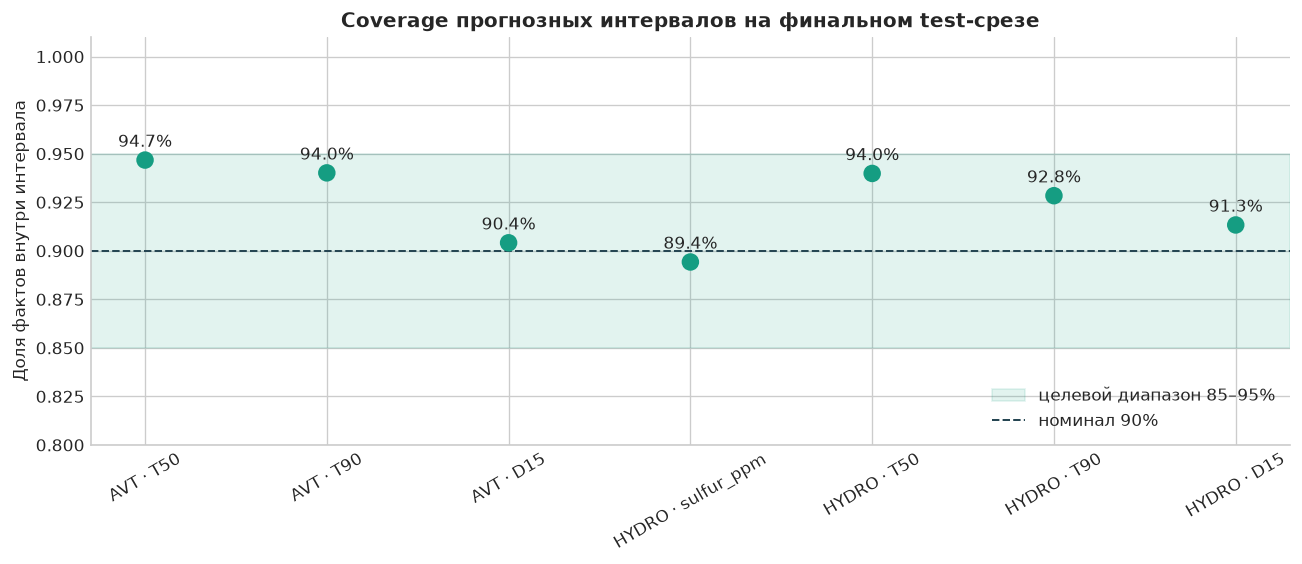

In [11]:
coverage = metrics_table.dropna(subset=["coverage 90%"]).copy()
coverage["label"] = coverage["model"].str.upper() + "  ·  " + coverage["target"]
coverage = coverage.sort_values("coverage 90%").reset_index(drop=True)
coverage["in_target"] = coverage["coverage 90%"].between(0.85, 0.95)
point_colors = coverage["in_target"].map({True: PALETTE["green"], False: PALETTE["red"]})

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.axvspan(0.85, 0.95, color=PALETTE["green"], alpha=0.10, zorder=0)
ax.axvline(0.90, color=PALETTE["ink"], linewidth=1.5, linestyle=(0, (4, 3)), zorder=1)
y = np.arange(len(coverage))
ax.hlines(y, 0.82, coverage["coverage 90%"], color=PALETTE["grid"], linewidth=2.0, zorder=1)
ax.scatter(coverage["coverage 90%"], y, s=115, c=point_colors, edgecolor="white", linewidth=1.3, zorder=3)
for row_y, value in zip(y, coverage["coverage 90%"]):
    ax.annotate(f"{value:.1%}", (value, row_y), xytext=(10, 0), textcoords="offset points", va="center", fontweight="bold", color=PALETTE["ink"])
ax.set_yticks(y, coverage["label"])
ax.set_xlim(0.82, 0.985)
ax.set_xlabel("Доля фактов внутри 90%-интервала")
ax.set_title("Coverage прогнозных интервалов · финальный test", loc="left")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
legend_items = [
    Patch(facecolor=PALETTE["green"], alpha=0.15, label="целевой коридор 85–95%"),
    plt.Line2D([0], [0], color=PALETTE["ink"], linestyle=(0, (4, 3)), label="номинал 90%"),
]
ax.legend(handles=legend_items, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.subplots_adjust(left=0.20, right=0.76, top=0.88, bottom=0.14)
plt.show()

## Прогноз против факта

Ниже прогнозы пересчитываются из сохранённых моделей. Полоса — причинный 90%-интервал, линия — центральный прогноз, точки — фактические измерения. Для серы дополнительно проведена спецификация 10 мг/кг.

In [12]:
def prediction_observations(model, frame, target, config, *, history=None) -> pd.DataFrame:
    evaluation = frame.sort_values("date").reset_index(drop=True)
    age_column = config.get("age_column")
    label_mask = _fresh_label_mask(
        evaluation,
        target_column=str(config["target_column"]),
        age_column=str(age_column) if age_column is not None else None,
    )
    positions = np.flatnonzero(label_mask.to_numpy())
    if positions.size == 0:
        return pd.DataFrame(columns=["date", "actual", "baseline", "prediction", "low", "high", "source_position"])

    baseline_all, prediction_all, low_all, high_all = _batch_prediction_arrays(
        model, evaluation, target=target, config=config
    )
    actual = pd.to_numeric(
        evaluation.iloc[positions][str(config["target_column"])], errors="coerce"
    ).to_numpy(dtype=float)
    valid = _physical_target_mask(actual, config)
    positions = positions[valid]
    actual = actual[valid]
    baseline = baseline_all[positions]
    prediction = prediction_all[positions]
    low = low_all[positions]
    high = high_all[positions]

    if history is not None and len(actual):
        low, high = _apply_online_interval_calibration(
            actual=actual, predicted=prediction, history=history
        )

    finite = np.isfinite(actual) & np.isfinite(prediction) & np.isfinite(low) & np.isfinite(high)
    return pd.DataFrame({
        "date": evaluation.iloc[positions[finite]]["date"].to_numpy(),
        "actual": actual[finite],
        "baseline": baseline[finite],
        "prediction": prediction[finite],
        "low": low[finite],
        "high": high[finite],
        "source_position": positions[finite],
    })


avt_history = build_calibration_history(
    quality_avt, periods["validation"], target_config=AVT_TARGET_CONFIG
)
hydro_history = build_calibration_history(
    quality_hydro, periods["validation"], target_config=HYDRO_TARGET_CONFIG
)

observations = {
    ("AVT", "T50"): prediction_observations(
        quality_avt, periods["test"], "T50", AVT_TARGET_CONFIG["T50"], history=avt_history.get("T50")
    ),
    ("Hydro", "sulfur_ppm"): prediction_observations(
        quality_hydro, periods["test"], "sulfur_ppm", HYDRO_TARGET_CONFIG["sulfur_ppm"], history=hydro_history.get("sulfur_ppm")
    ),
    ("Hydro", "T90"): prediction_observations(
        quality_hydro, periods["test"], "T90", HYDRO_TARGET_CONFIG["T90"], history=hydro_history.get("T90")
    ),
    ("Hydro", "D15"): prediction_observations(
        quality_hydro, periods["test"], "D15", HYDRO_TARGET_CONFIG["D15"], history=hydro_history.get("D15")
    ),
}
{f"{stage} {target}": len(frame) for (stage, target), frame in observations.items()}

{'AVT T50': 244, 'Hydro sulfur_ppm': 57889, 'Hydro T90': 349, 'Hydro D15': 173}

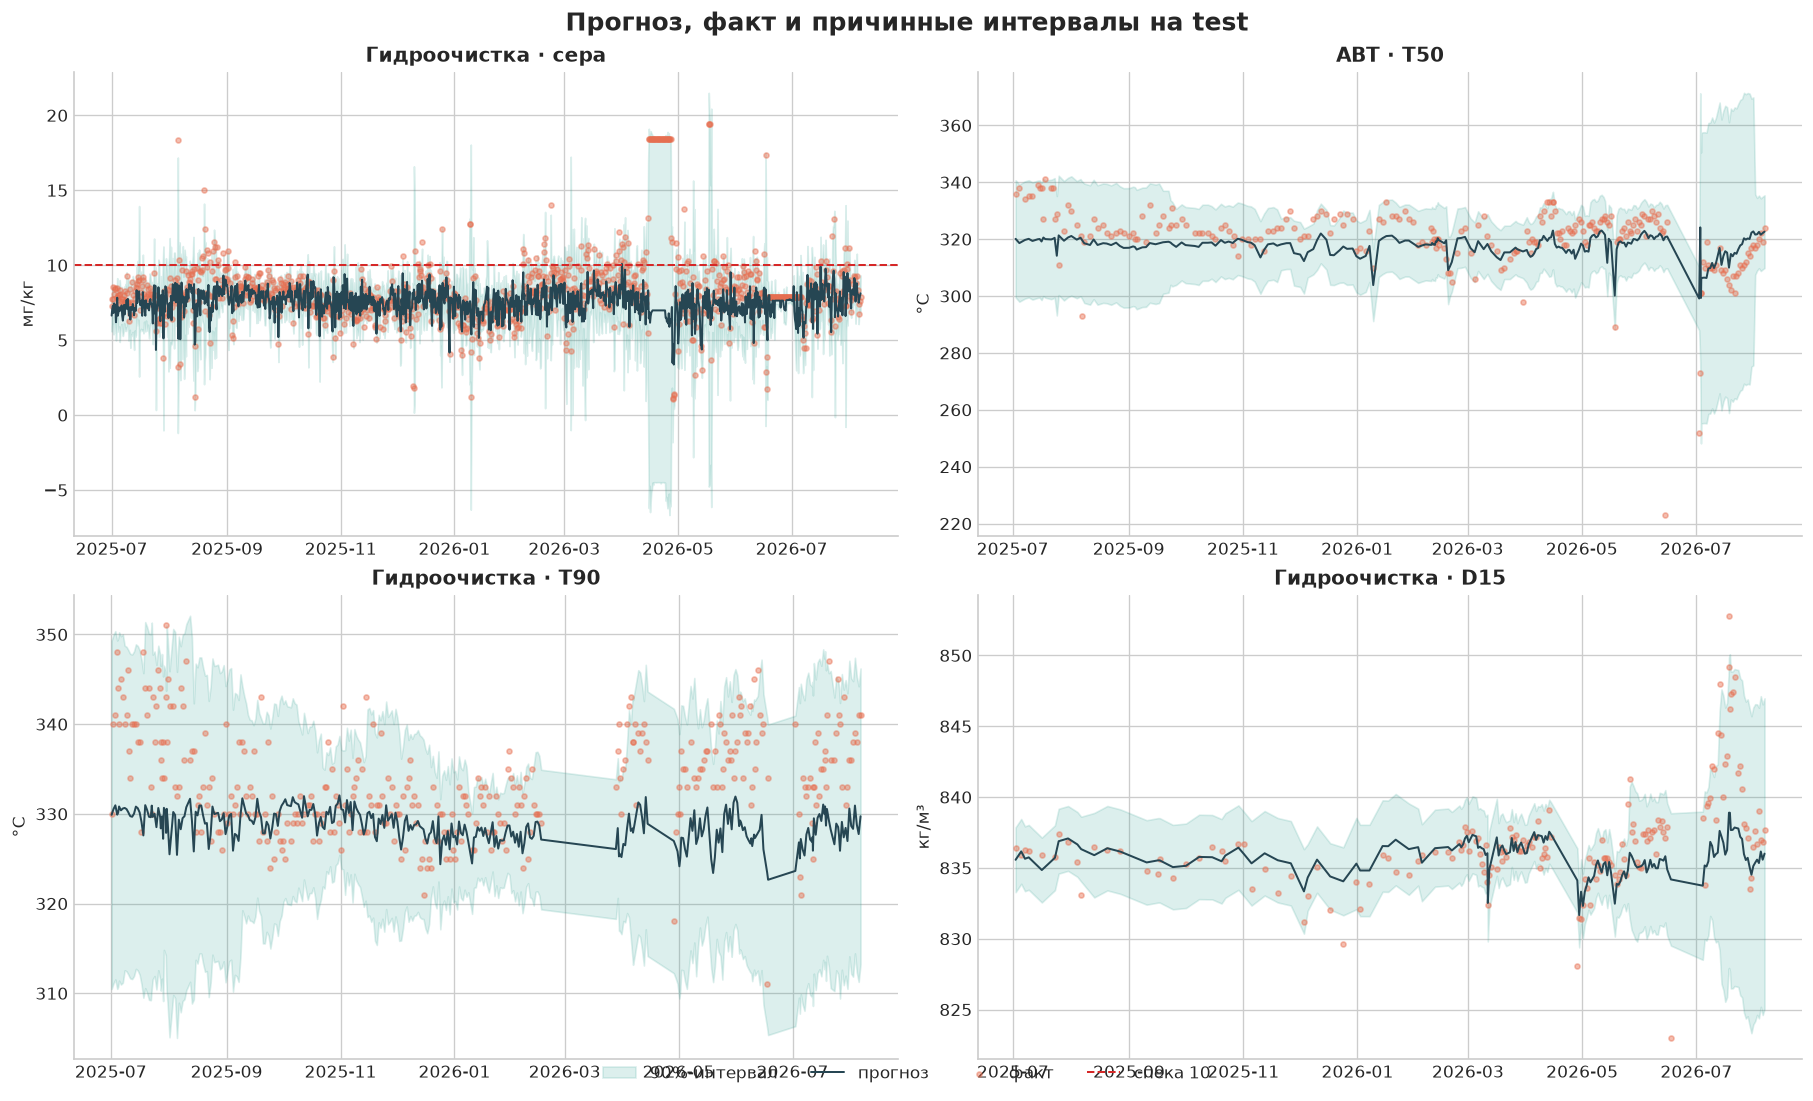

In [13]:
def plot_prediction(ax, data: pd.DataFrame, title: str, unit: str, *, spec_limit: float | None = None) -> None:
    if data.empty:
        ax.text(0.5, 0.5, "Недостаточно test-меток", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    shown = data.iloc[np.linspace(0, len(data) - 1, min(1200, len(data)), dtype=int)]
    dates = pd.to_datetime(shown["date"])
    ax.fill_between(dates, shown["low"], shown["high"], color=PALETTE["cyan"], alpha=0.18, linewidth=0, label="90%-интервал")
    ax.plot(dates, shown["prediction"], color=PALETTE["blue"], linewidth=1.8, label="прогноз", zorder=3)
    ax.scatter(dates, shown["actual"], color=PALETTE["orange"], s=13, alpha=0.58, edgecolor="white", linewidth=0.25, label="факт", rasterized=True, zorder=4)
    if spec_limit is not None:
        ax.axhline(spec_limit, color=PALETTE["red"], linestyle=(0, (5, 3)), linewidth=1.6, label=f"спека {spec_limit:g}", zorder=2)
    ax.set_title(title, loc="left")
    ax.set_ylabel(unit)
    ax.margins(x=0.01)
    ax.grid(axis="x", alpha=0.22)
    ax.tick_params(axis="x", labelrotation=18)


fig, axes = plt.subplots(2, 2, figsize=(16, 9.6))
plot_prediction(axes[0, 0], observations[("Hydro", "sulfur_ppm")], "Гидроочистка · сера", "мг/кг", spec_limit=10.0)
plot_prediction(axes[0, 1], observations[("AVT", "T50")], "АВТ · T50", "°C")
plot_prediction(axes[1, 0], observations[("Hydro", "T90")], "Гидроочистка · T90", "°C")
plot_prediction(axes[1, 1], observations[("Hydro", "D15")], "Гидроочистка · D15", "кг/м³")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=len(labels), columnspacing=2.2, handlelength=2.8)
fig.suptitle("Прогноз, факт и причинные интервалы на test", fontsize=17, fontweight="bold", y=0.985)
fig.subplots_adjust(left=0.07, right=0.98, top=0.84, bottom=0.10, hspace=0.38, wspace=0.20)
plt.show()

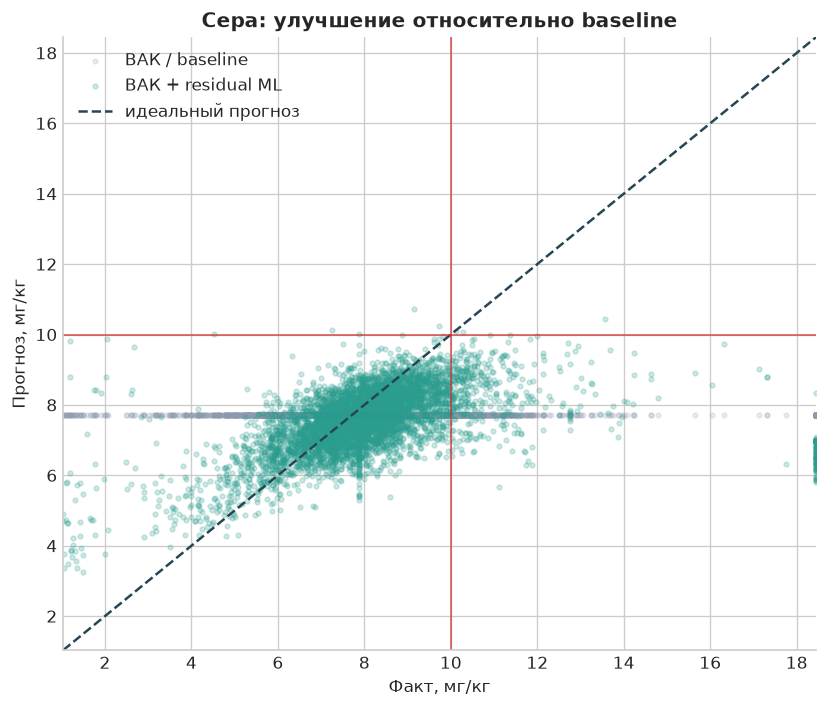

In [14]:
sulfur = observations[("Hydro", "sulfur_ppm")]
finite = sulfur[["actual", "prediction", "baseline"]].dropna()
sample = finite.iloc[np.linspace(0, len(finite) - 1, min(6000, len(finite)), dtype=int)]
lower = float(np.nanmin(sample[["actual", "prediction", "baseline"]].to_numpy()))
upper = float(np.nanpercentile(sample[["actual", "prediction", "baseline"]].to_numpy(), 99.5))

fig, ax = plt.subplots(figsize=(10.5, 7))
ax.scatter(sample["actual"], sample["baseline"], s=16, alpha=0.24, color=PALETTE["gray"], edgecolor="none", label="ВАК / baseline", rasterized=True)
ax.scatter(sample["actual"], sample["prediction"], s=18, alpha=0.38, color=PALETTE["blue"], edgecolor="white", linewidth=0.2, label="ВАК + residual ML", rasterized=True)
ax.plot([lower, upper], [lower, upper], color=PALETTE["ink"], linewidth=1.6, linestyle=(0, (5, 3)), label="идеальный прогноз")
ax.axvline(10, color=PALETTE["red"], linewidth=1.4, linestyle=":")
ax.axhline(10, color=PALETTE["red"], linewidth=1.4, linestyle=":", label="спека 10 мг/кг")
ax.set(xlim=(lower, upper), ylim=(lower, upper), xlabel="Факт, мг/кг", ylabel="Прогноз, мг/кг")
ax.set_title("Сера: улучшение относительно baseline", loc="left")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, labelspacing=1.0)
fig.subplots_adjust(left=0.10, right=0.72, top=0.90, bottom=0.12)
plt.show()

## SHAP: почему модель дала такой прогноз

Выбирается реальная test-точка, для которой верхняя граница интервала серы ниже спецификации. Столбцы показывают вклад признака в residual-модель относительно базового значения; положительный вклад повышает прогноз серы, отрицательный — снижает.

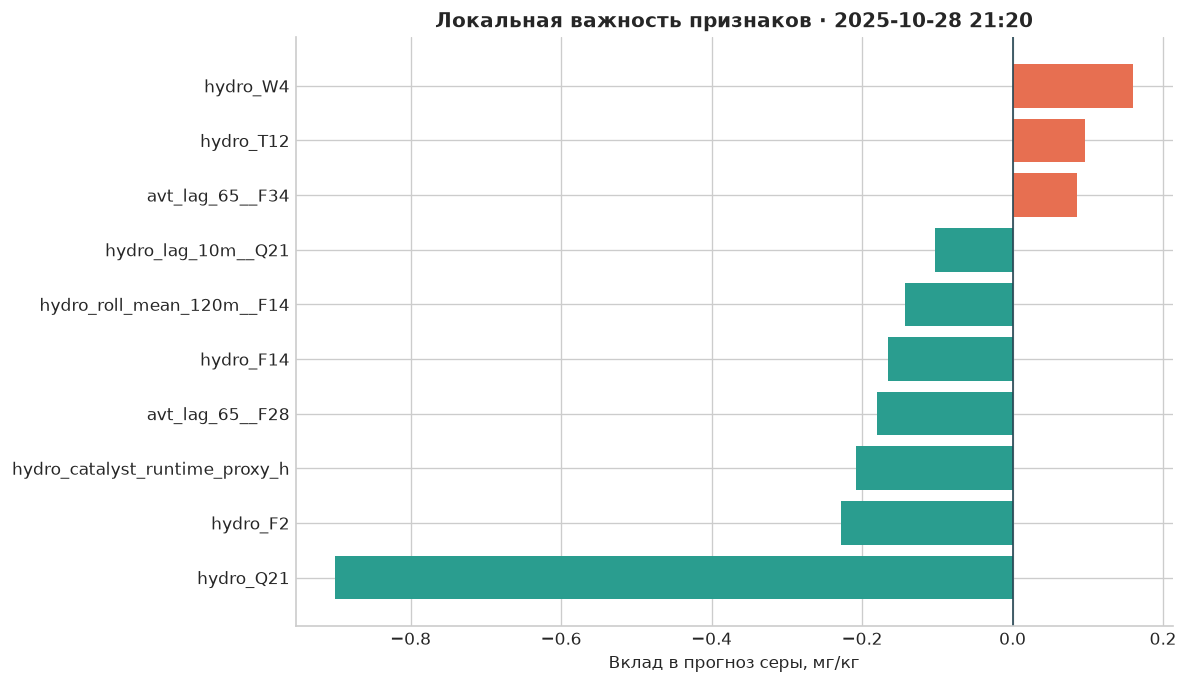

**Demo-точка:** `2025-10-28 21:20`  
**Сера:** 6.00 мг/кг (90% ДИ 3.77–8.23)  
**Риск > 10 мг/кг:** 1.1%  
**Уверенность:** `medium`

In [15]:
sulfur_candidates = sulfur.loc[
    sulfur["high"].le(9.0)
].copy()
if sulfur_candidates.empty:
    sulfur_candidates = sulfur.nsmallest(min(100, len(sulfur)), "high")

sulfur_candidates["distance_to_demo"] = (sulfur_candidates["prediction"] - 6.0).abs()
demo_row = None
for candidate in sulfur_candidates.sort_values("distance_to_demo").itertuples():
    proposed = periods["test"].iloc[[int(candidate.source_position)]].copy()
    if proposed[demo_control_tags].apply(pd.to_numeric, errors="coerce").notna().all(axis=None):
        demo_row = proposed
        break
if demo_row is None:
    raise RuntimeError("Не найдена test-точка с заполненными управляемыми тегами")

demo_prediction = quality_hydro.predict(demo_row)
explanation = quality_hydro.explain(demo_row)
shap_table = pd.DataFrame(explanation.top_features, columns=["feature", "SHAP"])
shap_table = shap_table.sort_values("SHAP")

colors = np.where(shap_table["SHAP"] >= 0, PALETTE["red"], PALETTE["blue"])
feature_labels = [name.replace("__", "  ·  ") for name in shap_table["feature"]]
fig, ax = plt.subplots(figsize=(12, 6.8))
bars = ax.barh(feature_labels, shap_table["SHAP"], color=colors, height=0.68, alpha=0.92)
ax.axvline(0, color=PALETTE["ink"], linewidth=1.2)
max_abs_shap = max(float(shap_table["SHAP"].abs().max()), 1e-9)
for bar, value in zip(bars, shap_table["SHAP"]):
    offset = 5 if value >= 0 else -5
    ax.annotate(f"{value:+.3f}", (value, bar.get_y() + bar.get_height() / 2), xytext=(offset, 0), textcoords="offset points", va="center", ha="left" if value >= 0 else "right", fontsize=9, fontweight="bold")
ax.set_xlim(-1.28 * max_abs_shap, 1.28 * max_abs_shap)
ax.set_xlabel("Вклад в прогноз серы, мг/кг")
ax.set_title(f"Локальная SHAP-важность · {demo_row.iloc[0]['date']:%Y-%m-%d %H:%M}", loc="left")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=PALETTE["red"], label="повышает серу"), Patch(color=PALETTE["blue"], label="снижает серу")], loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.subplots_adjust(left=0.32, right=0.79, top=0.89, bottom=0.14)
plt.show()

interval = demo_prediction.predictions["sulfur_ppm"]
display(Markdown(
    f"**Demo-точка:** `{demo_row.iloc[0]['date']:%Y-%m-%d %H:%M}`  \n"
    f"**Сера:** {interval.mean:.2f} мг/кг (90% ДИ {interval.low:.2f}–{interval.high:.2f})  \n"
    f"**Риск > 10 мг/кг:** {demo_prediction.spec_risk['sulfur_over_10']:.1%}  \n"
    f"**Уверенность:** `{demo_prediction.confidence}`"
))

## Парето-фронт на demo-точке

Оптимизируются четыре критерия: сера ↓, выход товарного ДТ ↑, энергозатраты ↓ и тяжесть изменения режима ↓. Диапазоны `hydro_T5`, `hydro_T11`, `avt_F30` берутся из единого feature registry и дополнительно ограничиваются отклонением ±3% от текущего режима. Жёсткое ограничение проверяет **весь** интервал серы, а не только среднее.

In [16]:
optimizer = ParetoOptimizer(
    quality_avt=quality_avt,
    quality_hydro=quality_hydro,
    blending=BlendingModel(),
)
constraints = optimizer.constraints_from_registry(
    hard={"sulfur_ppm": (0.0, 10.0)},
    max_deviation_pct=3.0,
    tags=demo_control_tags,
)

started = time.perf_counter()
variants = optimizer.find_pareto(demo_row, constraints, n_variants=10)
pareto_seconds = time.perf_counter() - started

pareto_rows = []
for rank, variant in enumerate(variants, start=1):
    pareto_rows.append({
        "rank": rank,
        **variant.action,
        **variant.metrics,
        "sulfur_high": variant.expected.predictions["sulfur_ppm"].high,
        "feasible": variant.feasible,
        "reason": variant.infeasible_reason,
    })
pareto_table = pd.DataFrame(pareto_rows)

display(
    pareto_table.style.format({
        **{tag: "{:.2f}" for tag in demo_control_tags},
        "sulfur": "{:.2f}",
        "sulfur_high": "{:.2f}",
        "yield": "{:.3f}",
        "energy": "{:.3f}",
        "severity": "{:.3f}",
    }).background_gradient(subset=["sulfur", "energy", "severity"], cmap="RdYlGn_r")
)
print(f"Оптимизатор вернул {len(variants)} вариантов за {pareto_seconds:.2f} с; допустимых: {sum(v.feasible for v in variants)}")

/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(


,rank,avt_F30,hydro_T11,hydro_T5,sulfur,yield,energy,severity,sulfur_high,feasible,reason
0,1,140.21,373.86,379.75,6.00,0.215,0.066,0.272,8.23,True,None
1,2,139.29,371.54,380.52,6.00,0.214,0.003,0.190,8.23,True,None
2,3,138.98,370.69,379.32,6.00,0.214,0.000,0.190,8.23,True,None
3,4,138.35,370.35,381.99,6.00,0.213,0.013,0.124,8.23,True,None
4,5,137.76,371.18,380.10,6.00,0.213,0.000,0.099,8.23,True,None
5,6,137.71,372.88,382.79,6.00,0.213,0.081,0.099,8.23,True,None
6,7,137.63,370.21,380.33,6.00,0.213,0.000,0.094,8.23,True,None
7,8,137.42,370.24,381.87,6.00,0.212,0.009,0.065,8.23,True,None
8,9,140.45,366.01,378.24,6.01,0.215,0.000,0.344,8.24,True,None
9,10,139.34,369.59,376.59,6.01,0.214,0.000,0.284,8.24,True,None


Оптимизатор вернул 10 вариантов за 2.39 с; допустимых: 10


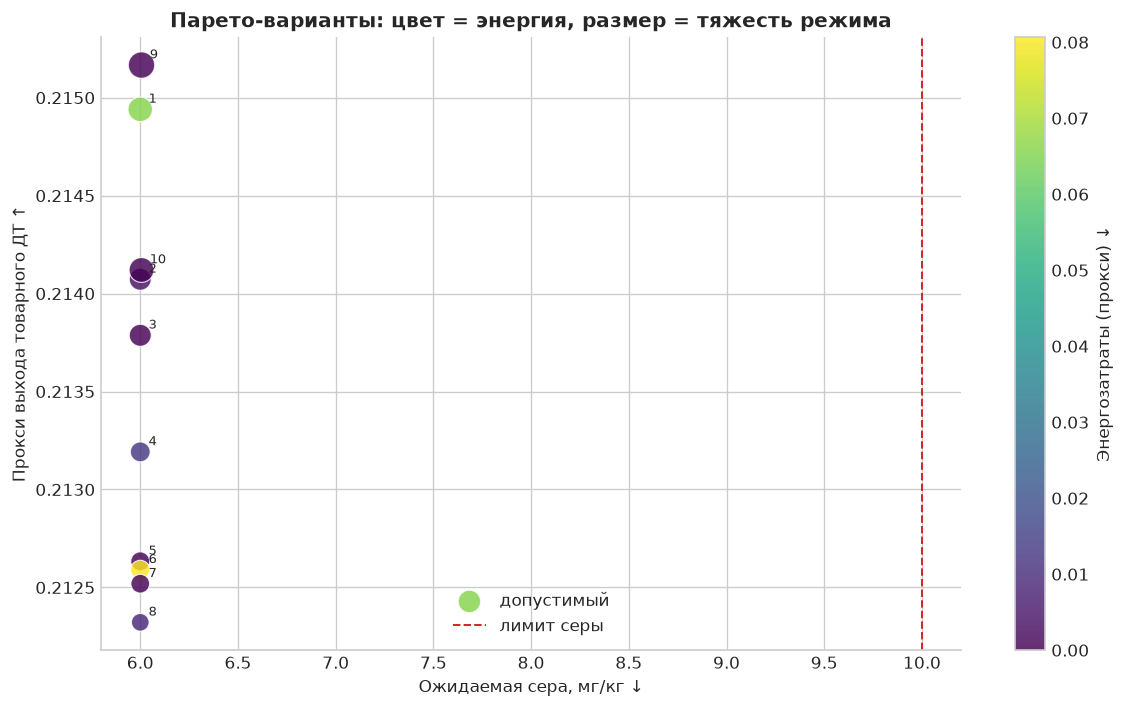

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))
feasible_mask = pareto_table["feasible"].astype(bool)
energy_min = float(pareto_table["energy"].min())
energy_max = float(pareto_table["energy"].max())
energy_norm = Normalize(vmin=energy_min, vmax=max(energy_max, energy_min + 1e-9))
annotation_offsets = [(8, 10), (8, -15), (-18, 10), (-18, -15), (12, 1), (-22, 1), (2, 15), (2, -20), (16, 14), (-26, -18)]
points = None
for mask, marker, label in [
    (feasible_mask, "o", "допустимый"),
    (~feasible_mask, "X", "отклонённый"),
]:
    subset = pareto_table.loc[mask]
    if subset.empty:
        continue
    sizes = 80 + 500 * subset["severity"].clip(lower=0)
    points = ax.scatter(
        subset["sulfur"], subset["yield"], c=subset["energy"], s=sizes,
        cmap="plasma", norm=energy_norm, marker=marker, alpha=0.90, edgecolor=PALETTE["ink"], linewidth=0.8, label=label, zorder=3,
    )
    for _, row in subset.iterrows():
        offset = annotation_offsets[(int(row["rank"]) - 1) % len(annotation_offsets)]
        ax.annotate(str(int(row["rank"])), (row["sulfur"], row["yield"]), xytext=offset, textcoords="offset points", fontsize=8, fontweight="bold", ha="center", va="center", bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": PALETTE["grid"], "alpha": 0.94}, arrowprops={"arrowstyle": "-", "color": PALETTE["gray"], "lw": 0.6})

ax.set_xlabel("Ожидаемая сера, мг/кг ↓")
ax.set_ylabel("Прокси выхода товарного ДТ ↑")
ax.set_title("Парето-фронт управляющих воздействий", loc="left")
ax.text(1.0, 1.025, "Жёсткий лимит: сера ≤ 10 мг/кг", transform=ax.transAxes, ha="right", va="bottom", color=PALETTE["red"], fontweight="bold")
ax.margins(x=0.16, y=0.18)
ax.grid(alpha=0.35, zorder=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, borderaxespad=0, columnspacing=2.0)
if points is not None:
    colorbar = fig.colorbar(points, ax=ax, pad=0.025, fraction=0.05)
    colorbar.set_label("Энергозатраты (прокси) ↓", labelpad=12)
fig.subplots_adjust(left=0.10, right=0.88, top=0.84, bottom=0.22)
plt.show()